# ARTI 403 Image Processing
## Lab 5: Spatial Filtering, Smoothing and Sharpening

**Name:** Mohammed Saeed Alamodi | **ID:** 2240009007

Covers the Lab 5 procedural step (unsharp masking) plus the three assessment tasks (box filter,
Gaussian filters and Laplacian sharpening).

Note: `cv2.imshow()` / `cv2.waitKey()` don't work inside a notebook, so matplotlib is used instead
to display the images.

### Setup
Make an `images` folder and save the images used in this lab. The manual reads `Parrot.png` but it
wasn't given with the lab files, so I used the astronaut image from skimage instead. The coffee
and cameraman images are used for the assessment tasks.

In [1]:
import os
import numpy as np
from PIL import Image
from skimage import data

os.makedirs('images', exist_ok=True)

if not os.path.exists('images/astronaut.png'):
    Image.fromarray(data.astronaut()).save('images/astronaut.png')

if not os.path.exists('images/coffee.png'):
    Image.fromarray(data.coffee()).save('images/coffee.png')

if not os.path.exists('images/cameraman.png'):
    Image.fromarray(data.camera()).save('images/cameraman.png')

print('Images ready:', sorted(os.listdir('images')))

Images ready: ['astronaut.png', 'cameraman.png', 'coffee.png']


## Procedural Steps
### Task #1: Unsharp Masking
Blur the image with a Gaussian, subtract the blurred version from the original to get the details
(the mask), then add the mask back scaled by `amount`.

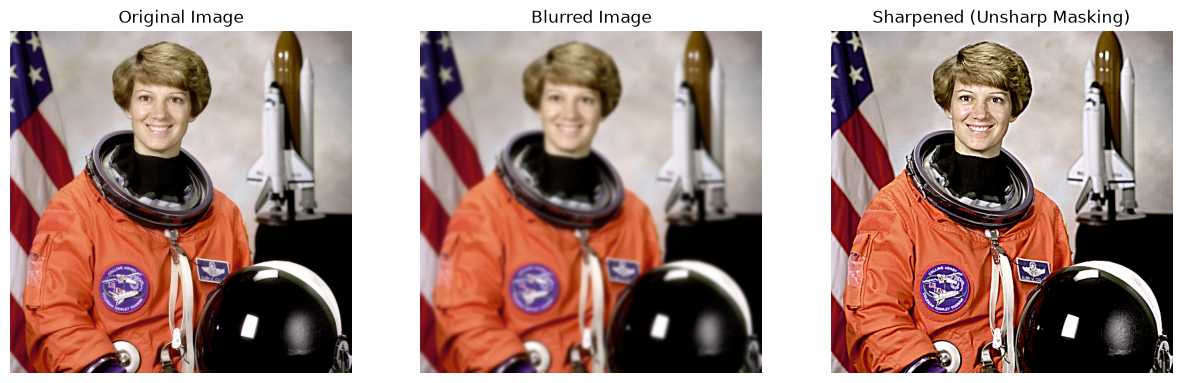

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read the image
image = cv2.imread('images/astronaut.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB

# Gaussian sigma
sigma = 2
# parameter
amount = 1.5

# Convert image to float32 for processing
image_float = image.astype(np.float32) / 255.0

# Apply Gaussian blur
blurred = cv2.GaussianBlur(image_float, (0, 0), sigmaX=sigma, sigmaY=sigma)

# Perform Unsharp Masking
sharpened = np.clip(image_float + amount * (image_float - blurred), 0, 1)

# Plot original, blurred, and sharpened images
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image)
ax[0].set_title("Original Image")
ax[0].axis("off")
ax[1].imshow(blurred)
ax[1].set_title("Blurred Image")
ax[1].axis("off")
ax[2].imshow(sharpened)
ax[2].set_title("Sharpened (Unsharp Masking)")
ax[2].axis("off")
plt.show()

**Observation:** The blurred image loses the fine details like the edges of the suit and the
text on the patches. After unsharp masking those edges look a lot crisper than in the original.
With amount = 1.5 it's a strong effect, and you can start to see some bright halos around high
contrast edges like the helmet and the flag.

## Practical Session Tasks (Assessment)

### Task #1: 7x7 box filter
Convolve an image with a 7x7 box filter and show the original and smoothed image side by side.
Every value in the kernel is 1/49 so each output pixel is the average of its 7x7 neighborhood.

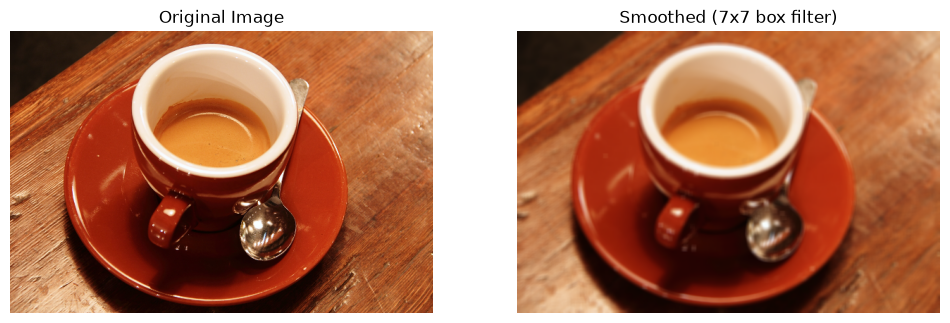

In [3]:
img = cv2.imread('images/coffee.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 7x7 box kernel, normalized so the weights add up to 1
box_kernel = np.ones((7, 7), np.float32) / 49
box_smoothed = cv2.filter2D(img, -1, box_kernel)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(img)
ax[0].set_title("Original Image")
ax[0].axis("off")
ax[1].imshow(box_smoothed)
ax[1].set_title("Smoothed (7x7 box filter)")
ax[1].axis("off")
plt.show()

**Observation:** The smoothed image is clearly blurrier. The wood grain on the table and the
small scratches mostly disappear, and the edges of the cup and spoon get soft. Since the box filter
gives every neighbor the same weight, the blur looks a bit blocky compared to a Gaussian.

### Task #2: 5x5 and 21x21 Gaussian filters
Apply a 5x5 Gaussian filter, then a 21x21 Gaussian filter, and show the three images side by side.
Passing `0` for sigma lets OpenCV compute it from the kernel size.

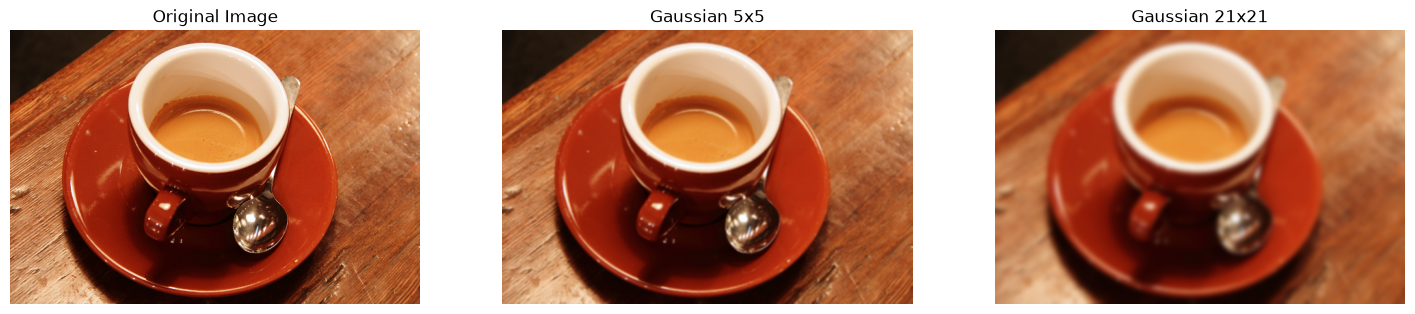

In [4]:
gauss_5 = cv2.GaussianBlur(img, (5, 5), 0)
gauss_21 = cv2.GaussianBlur(img, (21, 21), 0)

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].imshow(img)
ax[0].set_title("Original Image")
ax[0].axis("off")
ax[1].imshow(gauss_5)
ax[1].set_title("Gaussian 5x5")
ax[1].axis("off")
ax[2].imshow(gauss_21)
ax[2].set_title("Gaussian 21x21")
ax[2].axis("off")
plt.show()

**Observation:** The 5x5 Gaussian only softens the image a little, it's hard to tell apart from
the original unless you look at the fine texture on the wood. The 21x21 Gaussian blurs it a lot
more and most of the detail is gone, but you can still make out the shapes of the cup, saucer and
spoon. A bigger kernel (and so a bigger sigma) means more neighbors get averaged, so the blur is
stronger.

### Task #3: Sharpening with a 3x3 Laplacian filter
Steps:
1. Read the image
2. Convert it to float32
3. Use `cv2.Laplacian()`
4. Sharpen with `np.clip(image_float - laplacian, 0, 1)`
5. Plot the original, the Laplacian and the sharpened image

With `ksize=1` OpenCV uses the 3x3 kernel [[0, 1, 0], [1, -4, 1], [0, 1, 0]]. The center is
negative, which is why the Laplacian is subtracted from the image to sharpen it.

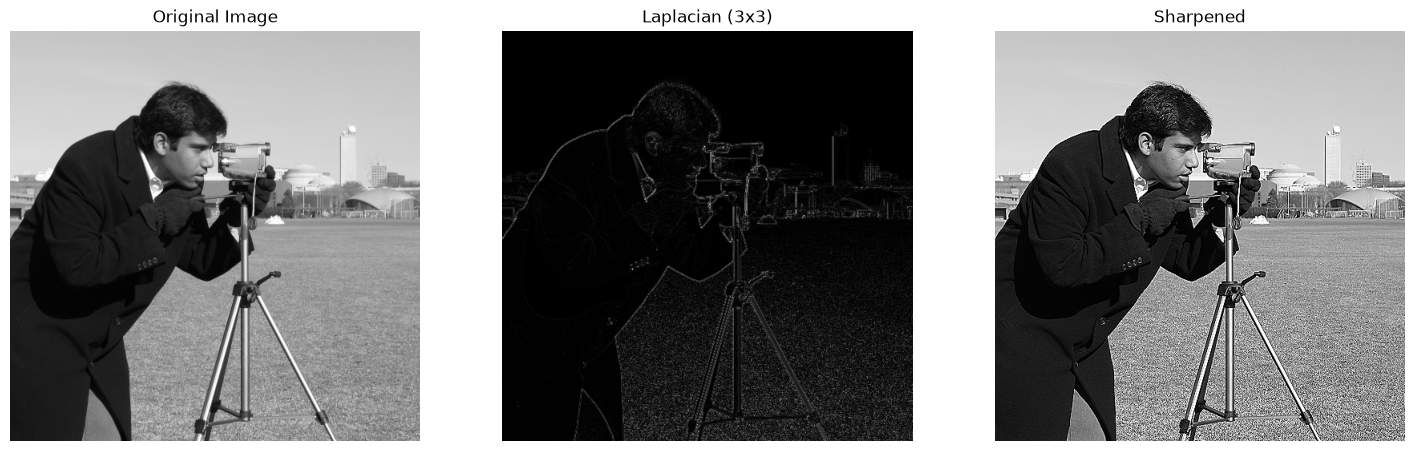

In [5]:
# Read the image in grayscale
gray = cv2.imread('images/cameraman.png', cv2.IMREAD_GRAYSCALE)

# Convert image to float32
image_float = gray.astype(np.float32) / 255.0

# 3x3 Laplacian
laplacian = cv2.Laplacian(image_float, cv2.CV_32F, ksize=1)

# Sharpen the image
sharpened = np.clip(image_float - laplacian, 0, 1)

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(image_float, cmap='gray')
ax[0].set_title("Original Image")
ax[0].axis("off")
# the Laplacian has negative values, so show its absolute value to see the edges
ax[1].imshow(np.abs(laplacian), cmap='gray')
ax[1].set_title("Laplacian (3x3)")
ax[1].axis("off")
ax[2].imshow(sharpened, cmap='gray')
ax[2].set_title("Sharpened")
ax[2].axis("off")
plt.show()

**Observation:** The Laplacian is close to zero in flat areas like the sky and only lights up
around edges, so it ends up looking like an outline of the cameraman, the tripod and the
buildings in the back. Subtracting it from the original makes those edges sharper and the coat and
camera look more detailed. It also makes the grass a bit noisier since the Laplacian picks up
small changes in intensity too.